In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
from src.database import connect_to_bd,query_db

query = """
DELETE
FROM ctgov.studies
"""

results = query_db(query)

for row in results:
    print(row)

ValueError: Only SELECT queries are allowed.

In [14]:
from src.nl_to_sql import retrive_db_from_query
retrive_db_from_query(instructions="Can you list 10 diseases in the database?")

Generated SQL query: SELECT DISTINCT name
FROM ctgov.conditions
WHERE name IS NOT NULL
ORDER BY name
LIMIT 10;


[("'In Situ Simulation'",),
 ('- Aortic Aneurysm',),
 ('- Critical Care',),
 ('- Egg Hypersensitivity',),
 ('- HIV',),
 ('- Medico-Economic Aspects (Evaluation of Medical Costs Related to the Three Strategies and Evaluation of Cost/Efficacy)',),
 ('- Rheumatoid Arthritis',),
 ('- Study Focus: Renal Retention of Lipid Microbubbles',),
 ('- Venous Leg Ulcers',),
 ('-Chronic Periodontitis',)]

In [3]:
from src.scientific_paper_rag import read_papers

In [5]:

read_papers(question="I want 3 symptoms of anorrexia")

'I don’t know—none of the files available to me list clinical symptoms of **anorexia nervosa**. The documents that mention “anorexia” are referring to **loss of appetite as a medication side effect/adverse event**, not the eating disorder  .'

In [4]:
read_papers(question=123)

An error occurred: Error code: 400 - {'error': {'message': "Invalid type for 'input': expected one of a string or array of input items, but got an integer instead.", 'type': 'invalid_request_error', 'param': 'input', 'code': 'invalid_type'}}


In [8]:
from src.agent import build_agent
app = build_agent()

In [6]:
from IPython.display import display, Image

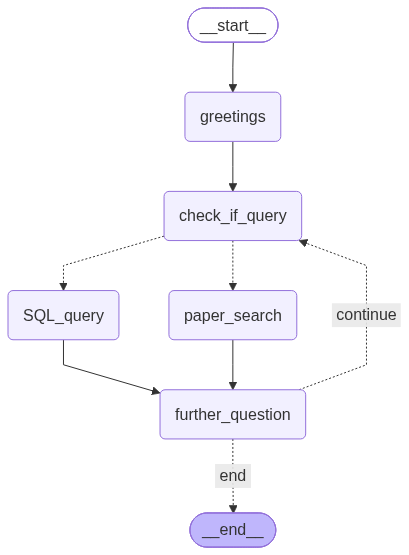

In [9]:
# Display the workflow
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state = {
  "start": True,
  "conversation": 0,
  "question": "",
  "query": "",
  "sql_query": "",
  "sql_answer": "",
  "rag_answer": "",
  "recursion_limit": 5,
  "memory": [],
  "continue_chat": True
}

In [11]:
final_state = app.invoke(
  initial_state,
  config={"recursion_limit": 20}
)

Hello! How can I help you?
Generated SQL query: SELECT DISTINCT
  s.nct_id,
  s.brief_title
FROM ctgov.studies AS s
JOIN ctgov.conditions AS c
  ON c.nct_id = s.nct_id
WHERE (
    c.name ILIKE '%ovarian cancer%'
 OR c.name ILIKE '%ovarian carcinoma%'
 OR c.name ILIKE '%epithelial ovarian%'
 OR c.name ILIKE '%malignant ovarian%'
)
AND NOT (
    c.name ILIKE '%ovarian failure%'
 OR c.name ILIKE '%ovarian insufficiency%'
 OR c.name ILIKE '%ovarian cyst%'
 OR c.name ILIKE '%ovarian function%'
)
ORDER BY s.start_date DESC NULLS LAST
LIMIT 10;
Error executing query: ERREUR:  pour SELECT DISTINCT, ORDER BY, les expressions doivent apparaître dans la
liste SELECT
LINE 19: ORDER BY s.start_date DESC NULLS LAST
                  ^

None
Ask another question or type 'exit' to stop:
Three biomarkers that are used to help **evaluate/monitor treatment response** in ovarian cancer include:

1) **CA-125 (cancer antigen 125)** – described as the best-characterized serologic biomarker in ovarian cancer 